In [1]:
import pandas as pd
from collections import Counter 
import math
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import libpysal as ps
from shapely.geometry import Point,Polygon,shape
from esda.moran import Moran
import seaborn as sns
import folium
from folium.plugins import HeatMapWithTime, TimestampedGeoJson,HeatMap
import fiona
from shapely.geometry import box
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
# from esda.smaup import Smaup

In [2]:
df_events = pd.read_csv("../geocodeur/from_hegp/data/data_octobre_2023/medical_event/patients_all_idf_EM.csv", sep = ";")

PM10_2017 = pd.read_csv("data/airparif_dir/airparif/pollution/pic/2017/pic_patients_pm10.csv", sep = ";")
PM10_2018 = pd.read_csv("data/airparif_dir/airparif/pollution/pic/2018/pic_patients_pm10.csv", sep = ";")
PM10_2019 = pd.read_csv("data/airparif_dir/airparif/pollution/pic/2019/pic_patients_pm10.csv", sep = ";")
df_patients = pd.read_csv("Resultats/Excels/patients_FR_IDF_geocoded_adultes_clinique_patho.csv", sep=";")
gdf_idf = gpd.read_file("../geocodeur/from_hegp/data/zones_geographiques/departements/IDF/dpt_idf.shp")

In [3]:
len(PM10_2017)

16385580

In [4]:
shapefile_path = "../geocodeur/from_hegp/data/zones_geographiques/departements/IDF/grille/grille_IDF.shp"

### PREPARATION DES DONNEES

In [3]:
#fonction pour convertir les dates en dateframe
def parse_date(date_str):
    for fmt in ('%d/%m/%Y', '%Y-%m-%d %H:%M:%S'):
        try:
            return pd.to_datetime(date_str, format=fmt)
        except ValueError:
            pass
    return pd.to_datetime(date_str, errors='coerce')

In [6]:
def pic_annuel(events, pm10, year):
    events['Date_debut'] = events['Date_debut'].apply(parse_date)
    events = events[events['Date_debut'].dt.year == year]
    


    pm10['date'] = pd.to_datetime(pm10['date'])
    pm10['mois']= pm10['date'].dt.month_name()
    pm10['annee'] = pm10['date'].dt.year
    pm10['pic'] = pm10['PM10']>50
    
    pm10_year = pm10[pm10['annee'] == year]

    pic_par_mois = pm10_year.groupby('mois')['pic'].sum().reset_index()
    

    all_months = ['January', 'February', 'March', 'April', 'May', 'June', 
                  'July', 'August', 'September', 'October', 'November', 'December']
    pic_par_mois = pic_par_mois.set_index('mois').reindex(all_months, fill_value=0).reset_index()

    print(pic_par_mois)

    plt.figure(figsize=(10, 6))
    plt.plot(pic_par_mois['mois'], pic_par_mois['pic'], marker='o', linestyle='-')
    plt.xlabel('Mois')
    plt.ylabel('Nombre de pics de PM10')
    plt.title(f'Nombre de pics de PM10 par mois en {year}')
    plt.xticks(rotation=45)  # Pour afficher tous les mois sur l'axe x
    plt.grid(True)
    plt.show() 

    return 

     
    


In [4]:
PM10 = pd.concat([PM10_2017, PM10_2018, PM10_2019], ignore_index=True)

         mois     pic
0     January  213310
1    February   45202
2       March       0
3       April       0
4         May       0
5        June       0
6        July       0
7      August       0
8   September       0
9     October       0
10   November      83
11   December     275


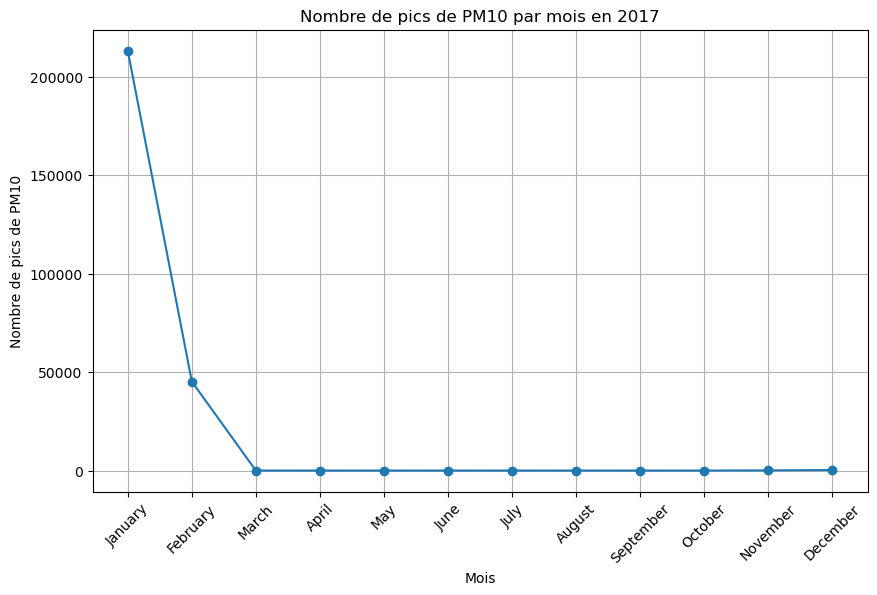

         mois    pic
0     January      0
1    February  56024
2       March      0
3       April      0
4         May      0
5        June      0
6        July      0
7      August      0
8   September      0
9     October      0
10   November      0
11   December     85


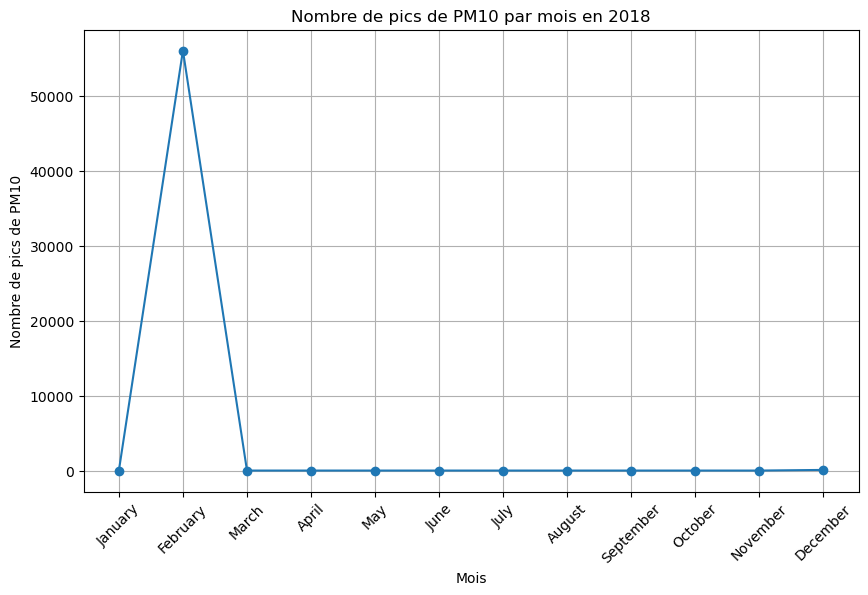

         mois     pic
0     January   22062
1    February  130296
2       March    1218
3       April       0
4         May       0
5        June       0
6        July   14577
7      August       0
8   September       0
9     October       0
10   November       0
11   December   34013


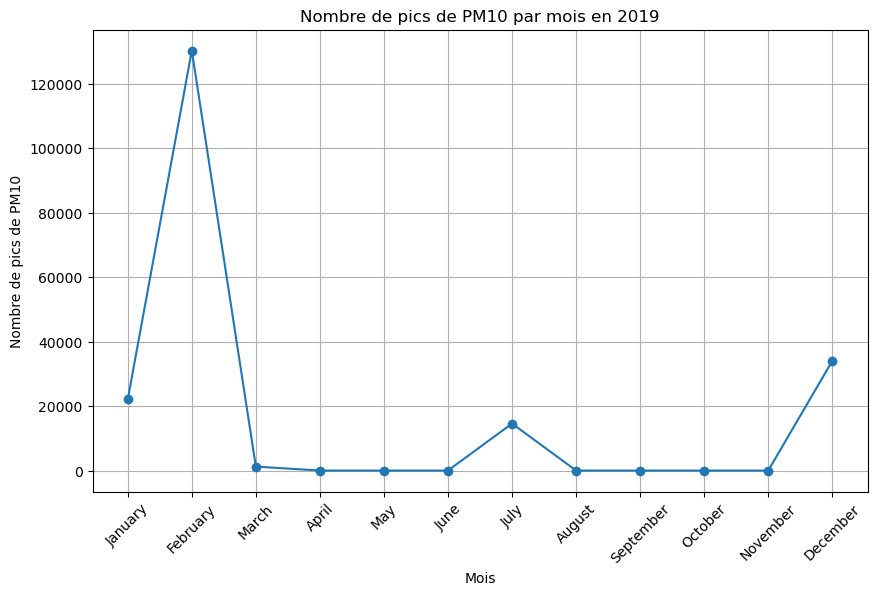

In [7]:
annee = [2017,2018,2019]

for an in annee:
    pic_annuel(df_events, PM10, an)
    

### ETUDE GEOSTATS: INDICE DE MORAN ET P-VALUE

In [8]:
def calcul_geostat (events, year):

    geometry = [Point(xy) for xy in zip(events['x'], events['y'])]
    
    events = gpd.GeoDataFrame(events, geometry=geometry, crs="EPSG:4326")
    # Reprojeter les données PM10 dans le système de coordonnées projetées (EPSG:2154)
    events = events.to_crs(epsg=2154)
    
    events['Date_debut'] = events['Date_debut'].apply(parse_date)
    events_year = events[events['Date_debut'].dt.year == year]

    gdf_EM = gpd.GeoDataFrame(events_year, geometry=events_year.geometry)

    # Agréger par mois et par position géographique
    gdf_EM['month_year'] = gdf_EM['Date_debut'].dt.to_period('M')
    counts = gdf_EM.groupby(['month_year', 'x', 'y']).size().reset_index(name='event_count')

    geometry = [Point(xy) for xy in zip(counts['x'], counts['y'])]
    gdf_cluster = gpd.GeoDataFrame(counts, geometry=geometry)

    print(counts)

    # Calculer Moran's I pour chaque mois
    moran_values = []
    
    for month_year, subset in counts.groupby('month_year'):
        event_values = subset['event_count'].values
        subset_geometry = [Point(xy) for xy in zip(subset['x'], subset['y'])]
        subset_gdf = gpd.GeoDataFrame(subset, geometry=subset_geometry)
        subset_w = ps.weights.DistanceBand.from_dataframe(subset_gdf, threshold=2, binary=True)
        mi = Moran(event_values, subset_w)
        moran_values.append((month_year, mi.I, mi.p_sim))

    moran_values = pd.DataFrame(moran_values).rename(columns = {0:'date',1:'moran_indice',2:'p_value'})
    print(moran_values)

    

    print('----------------------------------------------------------------------------------------------------')
    print('evolution des parametres d\'autocorrelation au cours de l\'annee')
    print('----------------------------------------------------------------------------------------------------')
    

    plt.figure(figsize=(12, 6))
    plt.plot(moran_values['date'].astype(str), moran_values['moran_indice'], marker='o', label="Moran's I")
    plt.xlabel('Mois')
    plt.ylabel("Moran's I")
    plt.title(f"Évolution de l'autocorrélation spatiale des événements médicaux en {year}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    plt.figure(figsize=(12, 6))
    plt.plot(moran_values['date'].astype(str), moran_values['p_value'], marker='o', label="p-value")
    plt.axhline(0.05, color='red', linestyle='--', label="Seuil de signification (0.05)")
    plt.xlabel('Mois')
    plt.ylabel("p-value")
    plt.title(f"Évolution des p-values des événements medicaux au cours de l\'annee {year}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('----------------------------------------------------------------------------------------------------')
    print('histogramme des parametres d\'autocorrelation')
    print('----------------------------------------------------------------------------------------------------')

    plt.figure(figsize=(10, 6))
    sns.histplot(moran_values['moran_indice'], bins=10, kde=True)
    plt.xlabel("Moran's I")
    plt.ylabel("Fréquence")
    plt.title(f"Distribution des valeurs de Moran's I en {year}")

    plt.figure(figsize=(10, 6))
    sns.histplot(moran_values['p_value'], bins=10, kde=True)
    plt.xlabel("p-value")
    plt.ylabel("Fréquence")
    plt.title(f"Distribution des p-values en {year}")
    
    
    plt.show()

    return

    





     month_year         x          y  event_count
0       2017-01  1.686899  48.995737            1
1       2017-01  1.694596  48.849446            1
2       2017-01  1.735039  48.949182            1
3       2017-01  1.758048  48.674451            1
4       2017-01  1.766153  48.719722            1
...         ...       ...        ...          ...
1328    2017-12  2.668876  49.052292            1
1329    2017-12  2.692390  48.653076            2
1330    2017-12  2.718345  48.403335            1
1331    2017-12  2.780570  48.799948            1
1332    2017-12  3.083240  48.813366            1

[1333 rows x 4 columns]


c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:220: RuntimeWarning: invalid value encountered in scalar power
  self.seI_norm = self.VI_norm ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:233: RuntimeWarning: invalid value encountered in scalar power
  self.seI_rand = VIR ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:233: RuntimeWarning: invalid value encountered in scalar power
  self.seI_rand = VIR ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:167: RuntimeWarning: divide by zero encountered in scalar divide
  self.z_norm = (self.I - self.EI) / self.seI_norm
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:220: RuntimeWarning: invalid value encountered in scalar power
  self.seI_norm = self.VI_norm ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:233: RuntimeWarning: invalid value encountered in scalar power
  s

       date  moran_indice  p_value
0   2017-01     -0.007874    0.269
1   2017-02     -0.008621    0.231
2   2017-03     -0.009709    0.182
3   2017-04     -0.010000    0.439
4   2017-05     -0.008929    0.012
5   2017-06     -0.009615    0.435
6   2017-07     -0.008772    0.025
7   2017-08     -0.009009    0.345
8   2017-09     -0.011628    0.160
9   2017-10     -0.008929    0.288
10  2017-11     -0.007752    0.452
11  2017-12     -0.009346    0.146
----------------------------------------------------------------------------------------------------
evolution des parametres d'autocorrelation au cours de l'annee
----------------------------------------------------------------------------------------------------


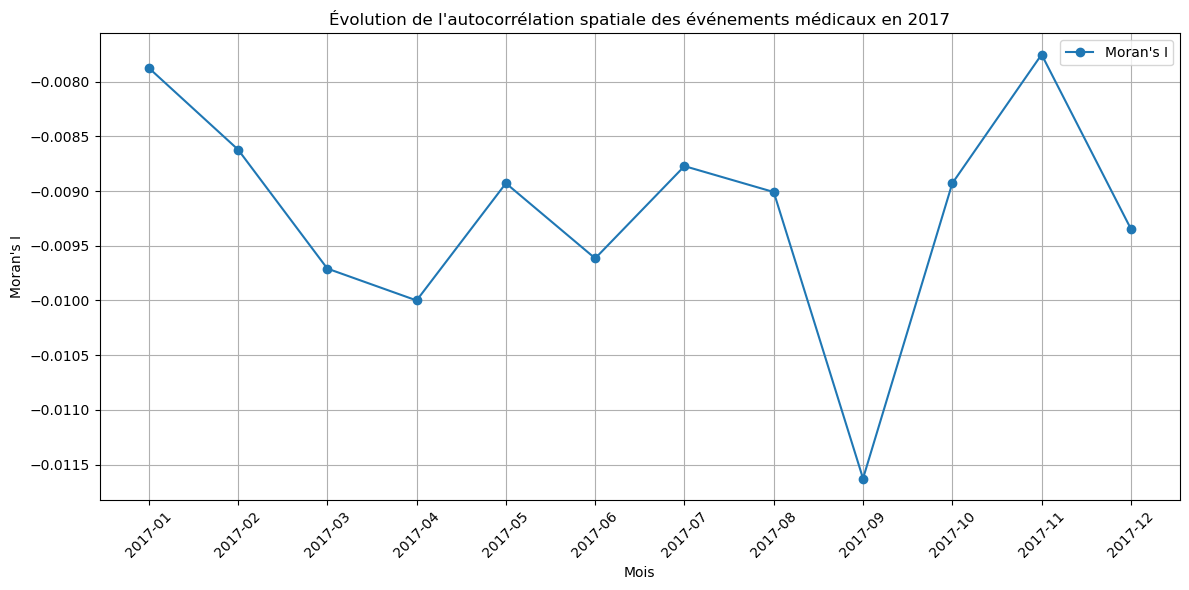

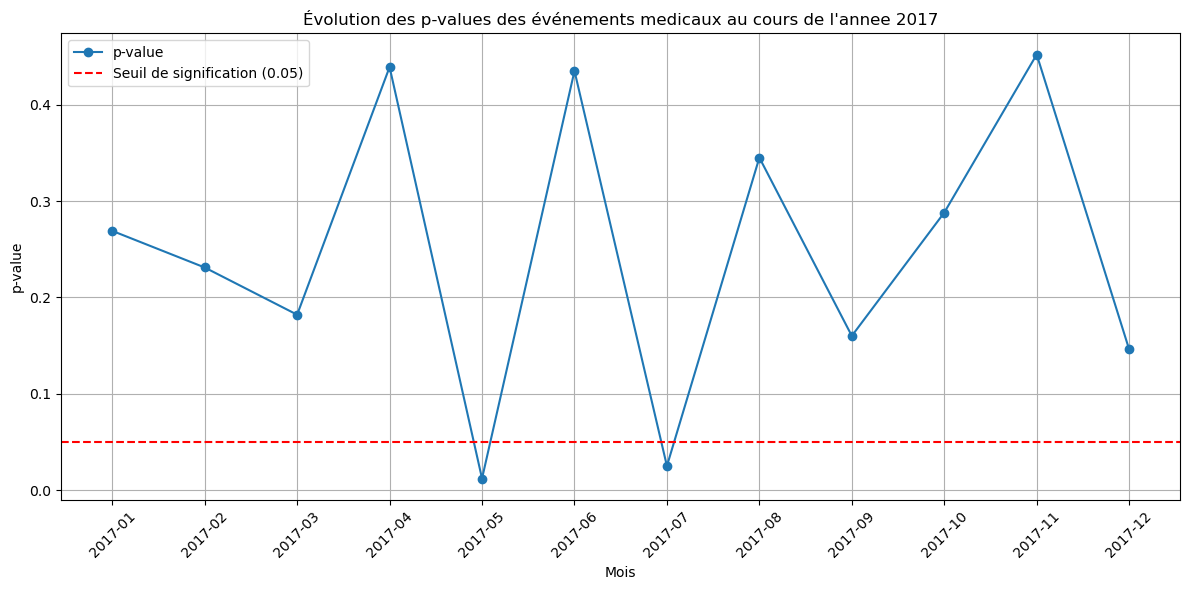

----------------------------------------------------------------------------------------------------
histogramme des parametres d'autocorrelation
----------------------------------------------------------------------------------------------------


c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


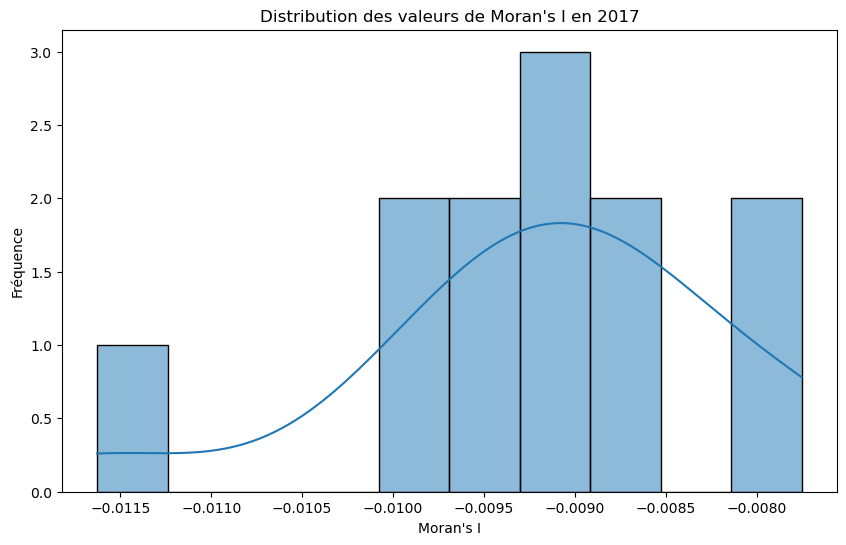

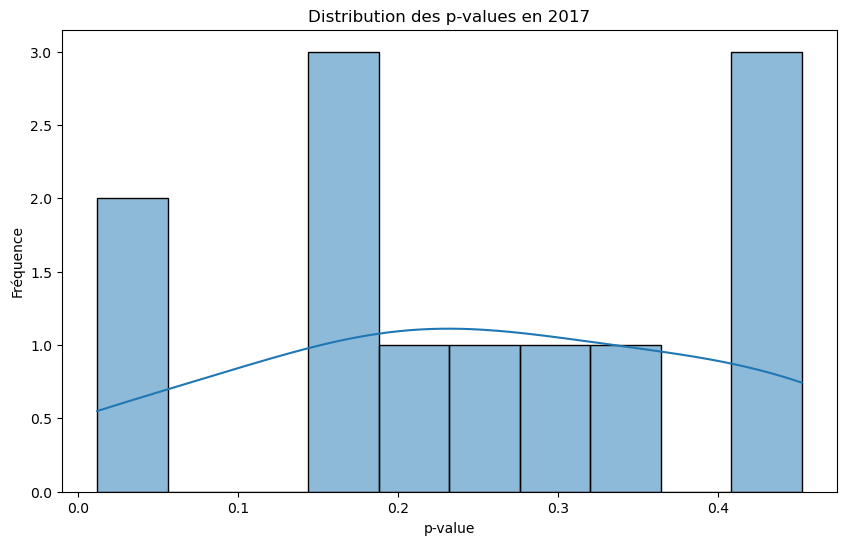

     month_year         x          y  event_count
0       2018-01  1.618455  48.903811            1
1       2018-01  1.697125  48.984869            2
2       2018-01  1.700194  48.995289            1
3       2018-01  1.744931  48.807938            1
4       2018-01  1.790680  48.797522            2
...         ...       ...        ...          ...
1227    2018-12  2.595839  48.567980            1
1228    2018-12  2.606906  48.945218            1
1229    2018-12  2.691349  48.402225            2
1230    2018-12  2.805417  49.072263            1
1231    2018-12  2.809894  48.373398            1

[1232 rows x 4 columns]


c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:220: RuntimeWarning: invalid value encountered in scalar power
  self.seI_norm = self.VI_norm ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:220: RuntimeWarning: invalid value encountered in scalar power
  self.seI_norm = self.VI_norm ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:233: RuntimeWarning: invalid value encountered in scalar power
  self.seI_rand = VIR ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:233: RuntimeWarning: invalid value encountered in scalar power
  self.seI_rand = VIR ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:220: RuntimeWarning: invalid value encountered in scalar power
  self.seI_norm = self.VI_norm ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:233: RuntimeWarning: invalid value encountered in scalar power
  self.seI_r

       date  moran_indice  p_value
0   2018-01     -0.008696    0.391
1   2018-02     -0.010526    0.483
2   2018-03     -0.011765    0.358
3   2018-04     -0.011905    0.031
4   2018-05     -0.010000    0.296
5   2018-06     -0.010000    0.418
6   2018-07     -0.009091    0.331
7   2018-08     -0.009346    0.035
8   2018-09     -0.011628    0.246
9   2018-10     -0.009259    0.389
10  2018-11     -0.009346    0.486
11  2018-12     -0.008130    0.096
----------------------------------------------------------------------------------------------------
evolution des parametres d'autocorrelation au cours de l'annee
----------------------------------------------------------------------------------------------------


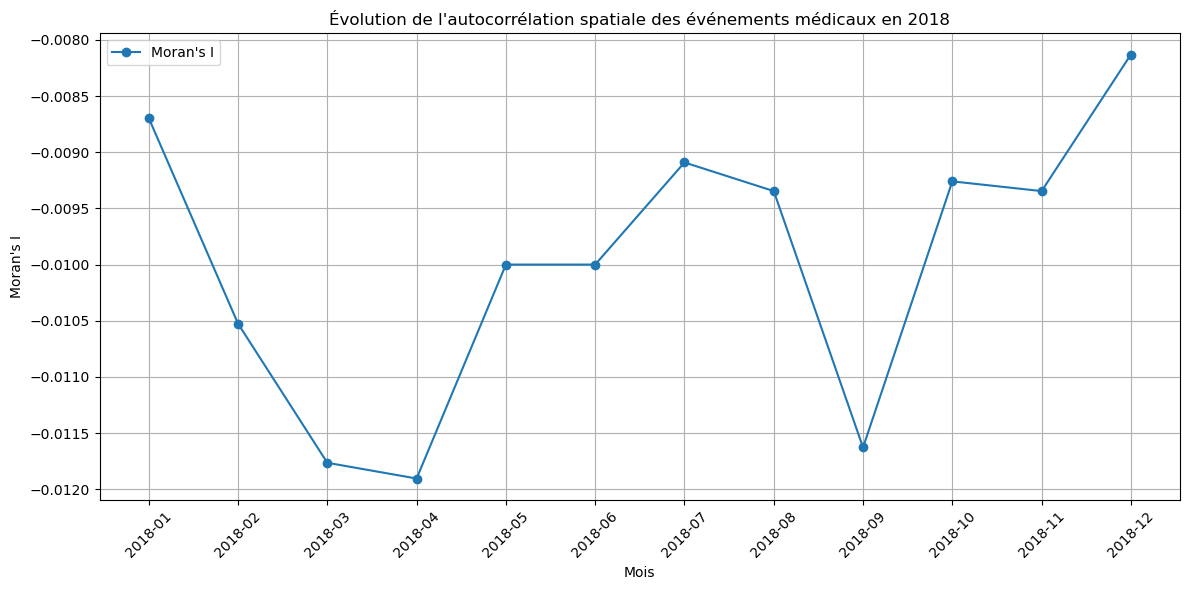

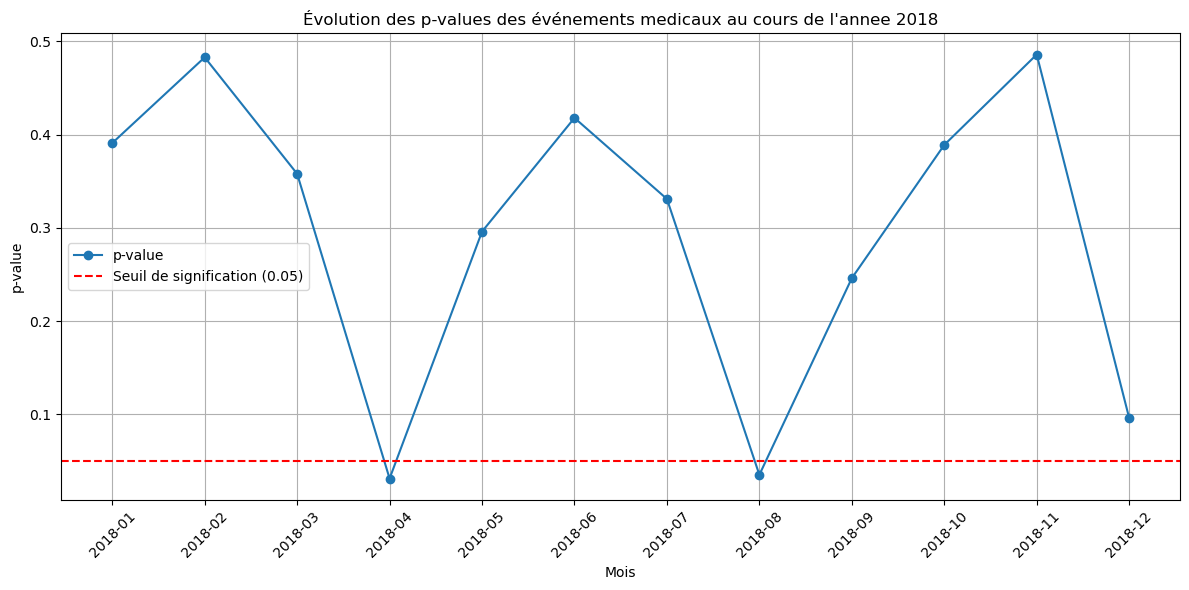

----------------------------------------------------------------------------------------------------
histogramme des parametres d'autocorrelation
----------------------------------------------------------------------------------------------------


c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


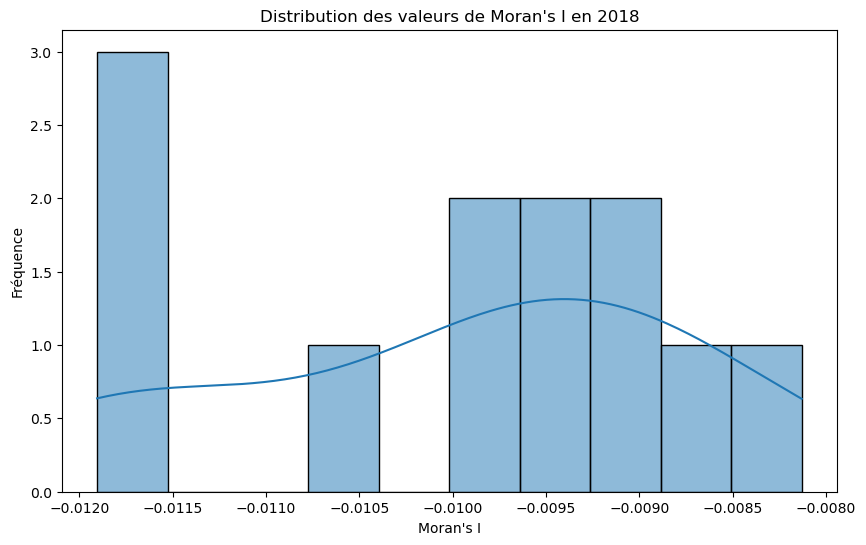

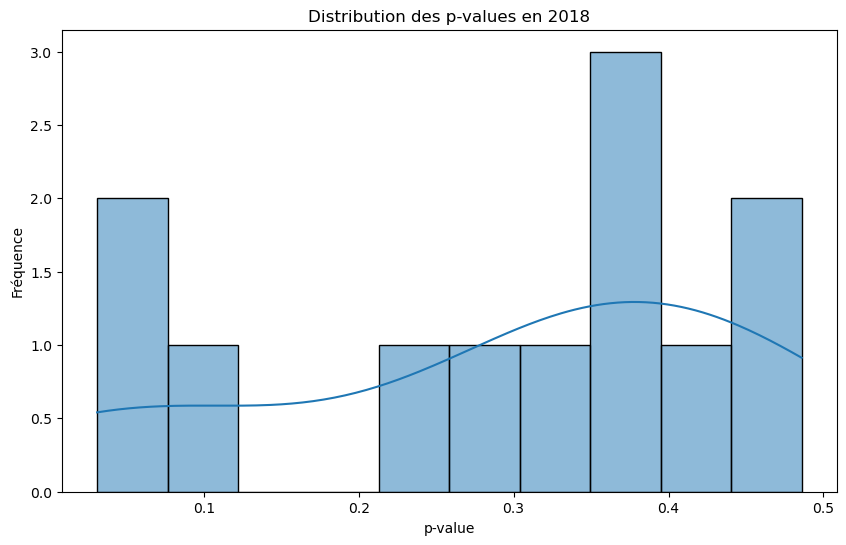

     month_year         x          y  event_count
0       2019-01  1.635599  49.039662            1
1       2019-01  1.727238  48.590497            2
2       2019-01  1.898353  48.819133            1
3       2019-01  1.926099  48.565416            1
4       2019-01  1.926280  49.011388            1
...         ...       ...        ...          ...
1504    2019-12  2.620298  48.843790            2
1505    2019-12  2.644117  48.539784            1
1506    2019-12  2.668985  48.542113            1
1507    2019-12  2.690160  48.874810            1
1508    2019-12  3.297831  48.483135            1

[1509 rows x 4 columns]


c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:220: RuntimeWarning: invalid value encountered in scalar power
  self.seI_norm = self.VI_norm ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:233: RuntimeWarning: invalid value encountered in scalar power
  self.seI_rand = VIR ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:220: RuntimeWarning: invalid value encountered in scalar power
  self.seI_norm = self.VI_norm ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:233: RuntimeWarning: invalid value encountered in scalar power
  self.seI_rand = VIR ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:220: RuntimeWarning: invalid value encountered in scalar power
  self.seI_norm = self.VI_norm ** (1 / 2.0)
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\esda\moran.py:233: RuntimeWarning: invalid value encountered in scalar power
  self.seI_r

       date  moran_indice  p_value
0   2019-01     -0.006757    0.328
1   2019-02     -0.006849    0.222
2   2019-03     -0.007407    0.159
3   2019-04     -0.006897    0.280
4   2019-05     -0.010204    0.054
5   2019-06     -0.009174    0.239
6   2019-07     -0.008696    0.114
7   2019-08     -0.008772    0.228
8   2019-09     -0.009524    0.311
9   2019-10     -0.006849    0.339
10  2019-11     -0.008264    0.005
11  2019-12     -0.008696    0.196
----------------------------------------------------------------------------------------------------
evolution des parametres d'autocorrelation au cours de l'annee
----------------------------------------------------------------------------------------------------


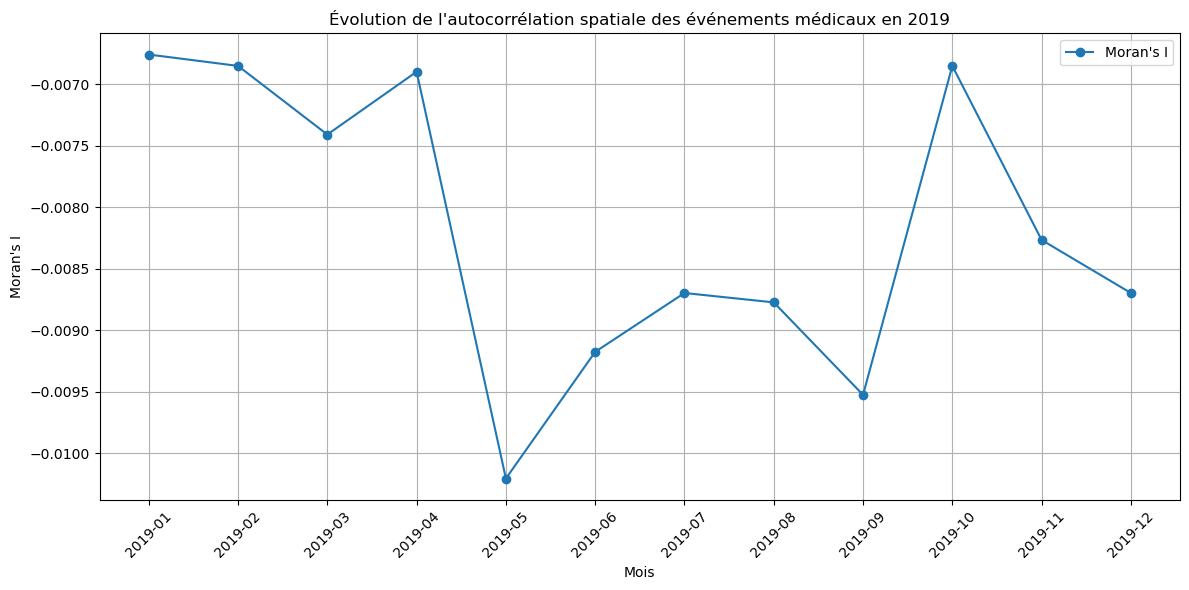

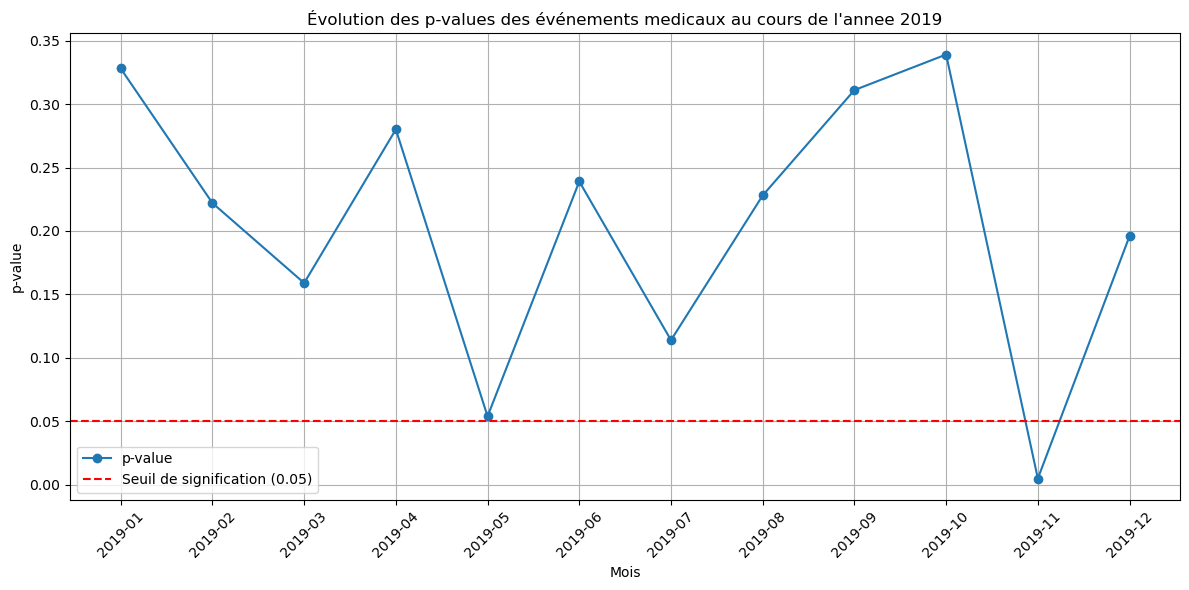

----------------------------------------------------------------------------------------------------
histogramme des parametres d'autocorrelation
----------------------------------------------------------------------------------------------------


c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


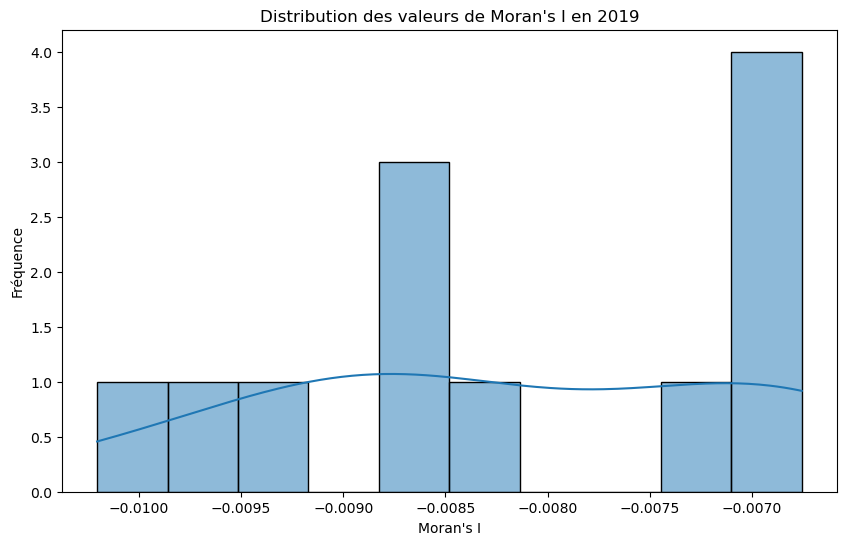

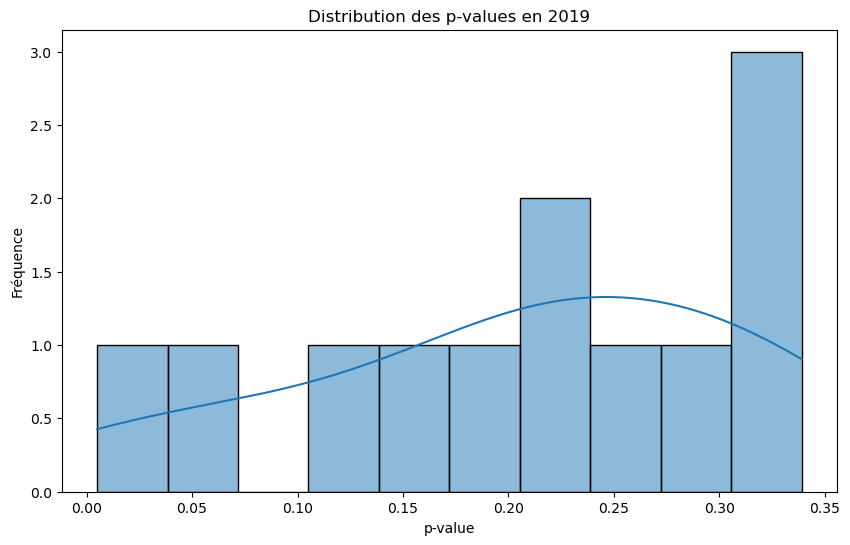

In [9]:
for an in annee:
    calcul_geostat(df_events,an)

### PICS DE POLLUTION ANNUELLE  PAR MAILLE DE 50*50M

In [17]:
df_events['Date_debut']= pd.to_datetime(df_events['Date_debut'])

In [18]:
df_events_2017 = df_events[df_events['Date_debut'].dt.year == 2017]
df_events_2018 = df_events[df_events['Date_debut'].dt.year == 2018]
df_events_2019 = df_events[df_events['Date_debut'].dt.year == 2019]

PM10_2017_EM =  PM10_2017.merge(df_events_2017, on='pseudo_provisoire')
PM10_2018_EM =  PM10_2018.merge(df_events_2018, on='pseudo_provisoire')
PM10_2019_EM =  PM10_2019.merge(df_events_2019, on='pseudo_provisoire')


# Créer un GeoDataFrame pour les données PM10 avec les coordonnées initiales (EPSG:4326)
geometry = [Point(xy) for xy in zip(PM10_2017_EM['x'], PM10_2017_EM['y'])]
PM10_2017_EM = gpd.GeoDataFrame(PM10_2017_EM, geometry=geometry, crs="EPSG:4326")

geometry = [Point(xy) for xy in zip(PM10_2018_EM['x'], PM10_2018_EM['y'])]
PM10_2018_EM = gpd.GeoDataFrame(PM10_2018_EM, geometry=geometry, crs="EPSG:4326")

geometry = [Point(xy) for xy in zip(PM10_2019_EM['x'], PM10_2019_EM['y'])]
PM10_2019_EM = gpd.GeoDataFrame(PM10_2019_EM, geometry=geometry, crs="EPSG:4326")


# Reprojeter les données PM10 dans le système de coordonnées projetées (EPSG:2154)
PM10_2017_EM = PM10_2017_EM.to_crs(epsg=2154)
PM10_2018_EM = PM10_2018_EM.to_crs(epsg=2154)
PM10_2019_EM = PM10_2019_EM.to_crs(epsg=2154)

In [19]:
geometry = [Point(xy) for xy in zip(df_events['x'], df_events['y'])]
gdf_events = gpd.GeoDataFrame(df_events, geometry=geometry, crs="EPSG:4326")

In [20]:
#Delimitation des boundaries de l'IDF
min_x, min_y, max_x, max_y = gdf_idf.total_bounds

#paquets de mailles
x_bins = np.arange(min_x, max_x + 50, 50)
y_bins = np.arange(min_y, max_y + 50, 50)

mailles = [box(x, y, x + 50, y + 50) for x in x_bins for y in y_bins]
grid_gdf = gpd.GeoDataFrame(geometry=mailles, crs=gdf_idf.crs)


In [21]:
joined_2017 = gpd.sjoin(PM10_2017_EM.to_crs(grid_gdf.crs), grid_gdf, how='left', op='within')
joined_2018 = gpd.sjoin(PM10_2018_EM.to_crs(grid_gdf.crs), grid_gdf, how='left', op='within')
joined_2019 = gpd.sjoin(PM10_2019_EM.to_crs(grid_gdf.crs), grid_gdf, how='left', op='within')

c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\IPython\core\interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\IPython\core\interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):
c:\Users\lpokambo\.conda\envs\Loice\lib\site-packages\IPython\core\interactiveshell.py:3517: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [22]:
# Ajouter les colonnes 'date', 'mois' et 'pic'
for df in [joined_2017, joined_2018, joined_2019]:
    df['date'] = pd.to_datetime(df['Date_debut'])
    df['mois'] = df['date'].dt.strftime('%Y-%m')
    df['pic'] = df['PM10'] > 50

In [23]:
def count_unique_pics(df):
    df_pics = df[df['PM10'] > 50]
    df_pics = df_pics.groupby(['index_right', df_pics['date'].dt.strftime('%Y-%m')]).size().reset_index(name='pic_maille')
    df_pics = df_pics.groupby(['index_right']).size().reset_index(name='pic_count')
    return df_pics

In [24]:
pics_counts = count_unique_pics(joined_2017)

In [25]:
pics_counts

,index_right,pic_count
0,305311,2
1,473325,1
2,528187,1
3,540730,1
4,826644,1
...,...,...
1000,5407673,1
1001,5509443,1
1002,6000675,1
1003,6276577,1


In [26]:
pics_counts_2018 = count_unique_pics(joined_2018)

In [27]:
pics_counts_2018

,index_right,pic_count
0,305311,2
1,340662,1
2,373252,1
3,460693,3
4,518155,1
...,...,...
916,4980495,1
917,5228553,1
918,5283693,1
919,5356215,1


In [28]:
pics_counts_2019 = count_unique_pics(joined_2019)

In [29]:
# Fusionner avec le GeoDataFrame des mailles pour inclure toutes les mailles
grid_gdf_2017 = grid_gdf.merge(pics_counts, left_index=True, right_on='index_right', how='left')
# Remplacer les NaN par 0 pour les mailles sans pics
grid_gdf_2017['pic_count'].fillna(0, inplace=True)


C:\Users\lpokambo\AppData\Local\Temp\ipykernel_4612\439953684.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  grid_gdf_2017['pic_count'].fillna(0, inplace=True)


In [30]:
# Fusionner avec le GeoDataFrame des mailles pour inclure toutes les mailles
grid_gdf_2018 = grid_gdf.merge(pics_counts_2018, left_index=True, right_on='index_right', how='left')
# Remplacer les NaN par 0 pour les mailles sans pics
grid_gdf_2018['pic_count'].fillna(0, inplace=True)

C:\Users\lpokambo\AppData\Local\Temp\ipykernel_4612\269257856.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  grid_gdf_2018['pic_count'].fillna(0, inplace=True)


In [31]:
grid_gdf_2018.columns

Index(['geometry', 'index_right', 'pic_count'], dtype='object')

In [32]:
# Fusionner avec le GeoDataFrame des mailles pour inclure toutes les mailles
grid_gdf_2019 = grid_gdf.merge(pics_counts_2019, left_index=True, right_on='index_right', how='left')
# Remplacer les NaN par 0 pour les mailles sans pics
grid_gdf_2019['pic_count'].fillna(0, inplace=True)

C:\Users\lpokambo\AppData\Local\Temp\ipykernel_4612\1999004332.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  grid_gdf_2019['pic_count'].fillna(0, inplace=True)


In [33]:
grid_gdf_2018

,geometry,index_right,pic_count
NaN,"POLYGON ((586551.700 6780071.500, 586551.700 6...",0,0.0
NaN,"POLYGON ((586551.700 6780121.500, 586551.700 6...",1,0.0
NaN,"POLYGON ((586551.700 6780171.500, 586551.700 6...",2,0.0
NaN,"POLYGON ((586551.700 6780221.500, 586551.700 6...",3,0.0
NaN,"POLYGON ((586551.700 6780271.500, 586551.700 6...",4,0.0
...,...,...,...
NaN,"POLYGON ((741051.700 6905221.500, 741051.700 6...",7752223,0.0
NaN,"POLYGON ((741051.700 6905271.500, 741051.700 6...",7752224,0.0
NaN,"POLYGON ((741051.700 6905321.500, 741051.700 6...",7752225,0.0
NaN,"POLYGON ((741051.700 6905371.500, 741051.700 6...",7752226,0.0


In [34]:
grid_gdf_2018.pic_count.unique()

array([0., 2., 1., 3., 4., 5., 6., 7.])

In [35]:
# grid_gdf_2017.to_csv("../geocodeur/from_hegp/data/zones_geographiques/departements/IDF/pic_grid_count_2017.csv",sep=";")

In [36]:
# grid_gdf_2018.to_csv("../geocodeur/from_hegp/data/zones_geographiques/departements/IDF/pic_pm10_grid_count_2018.csv",sep=";")

In [37]:
grid_gdf_2019.to_csv("../geocodeur/from_hegp/data/zones_geographiques/departements/IDF/pic_pm10_grid_count_2019.csv",sep=";")

TypeError: 'float' object cannot be interpreted as an integer

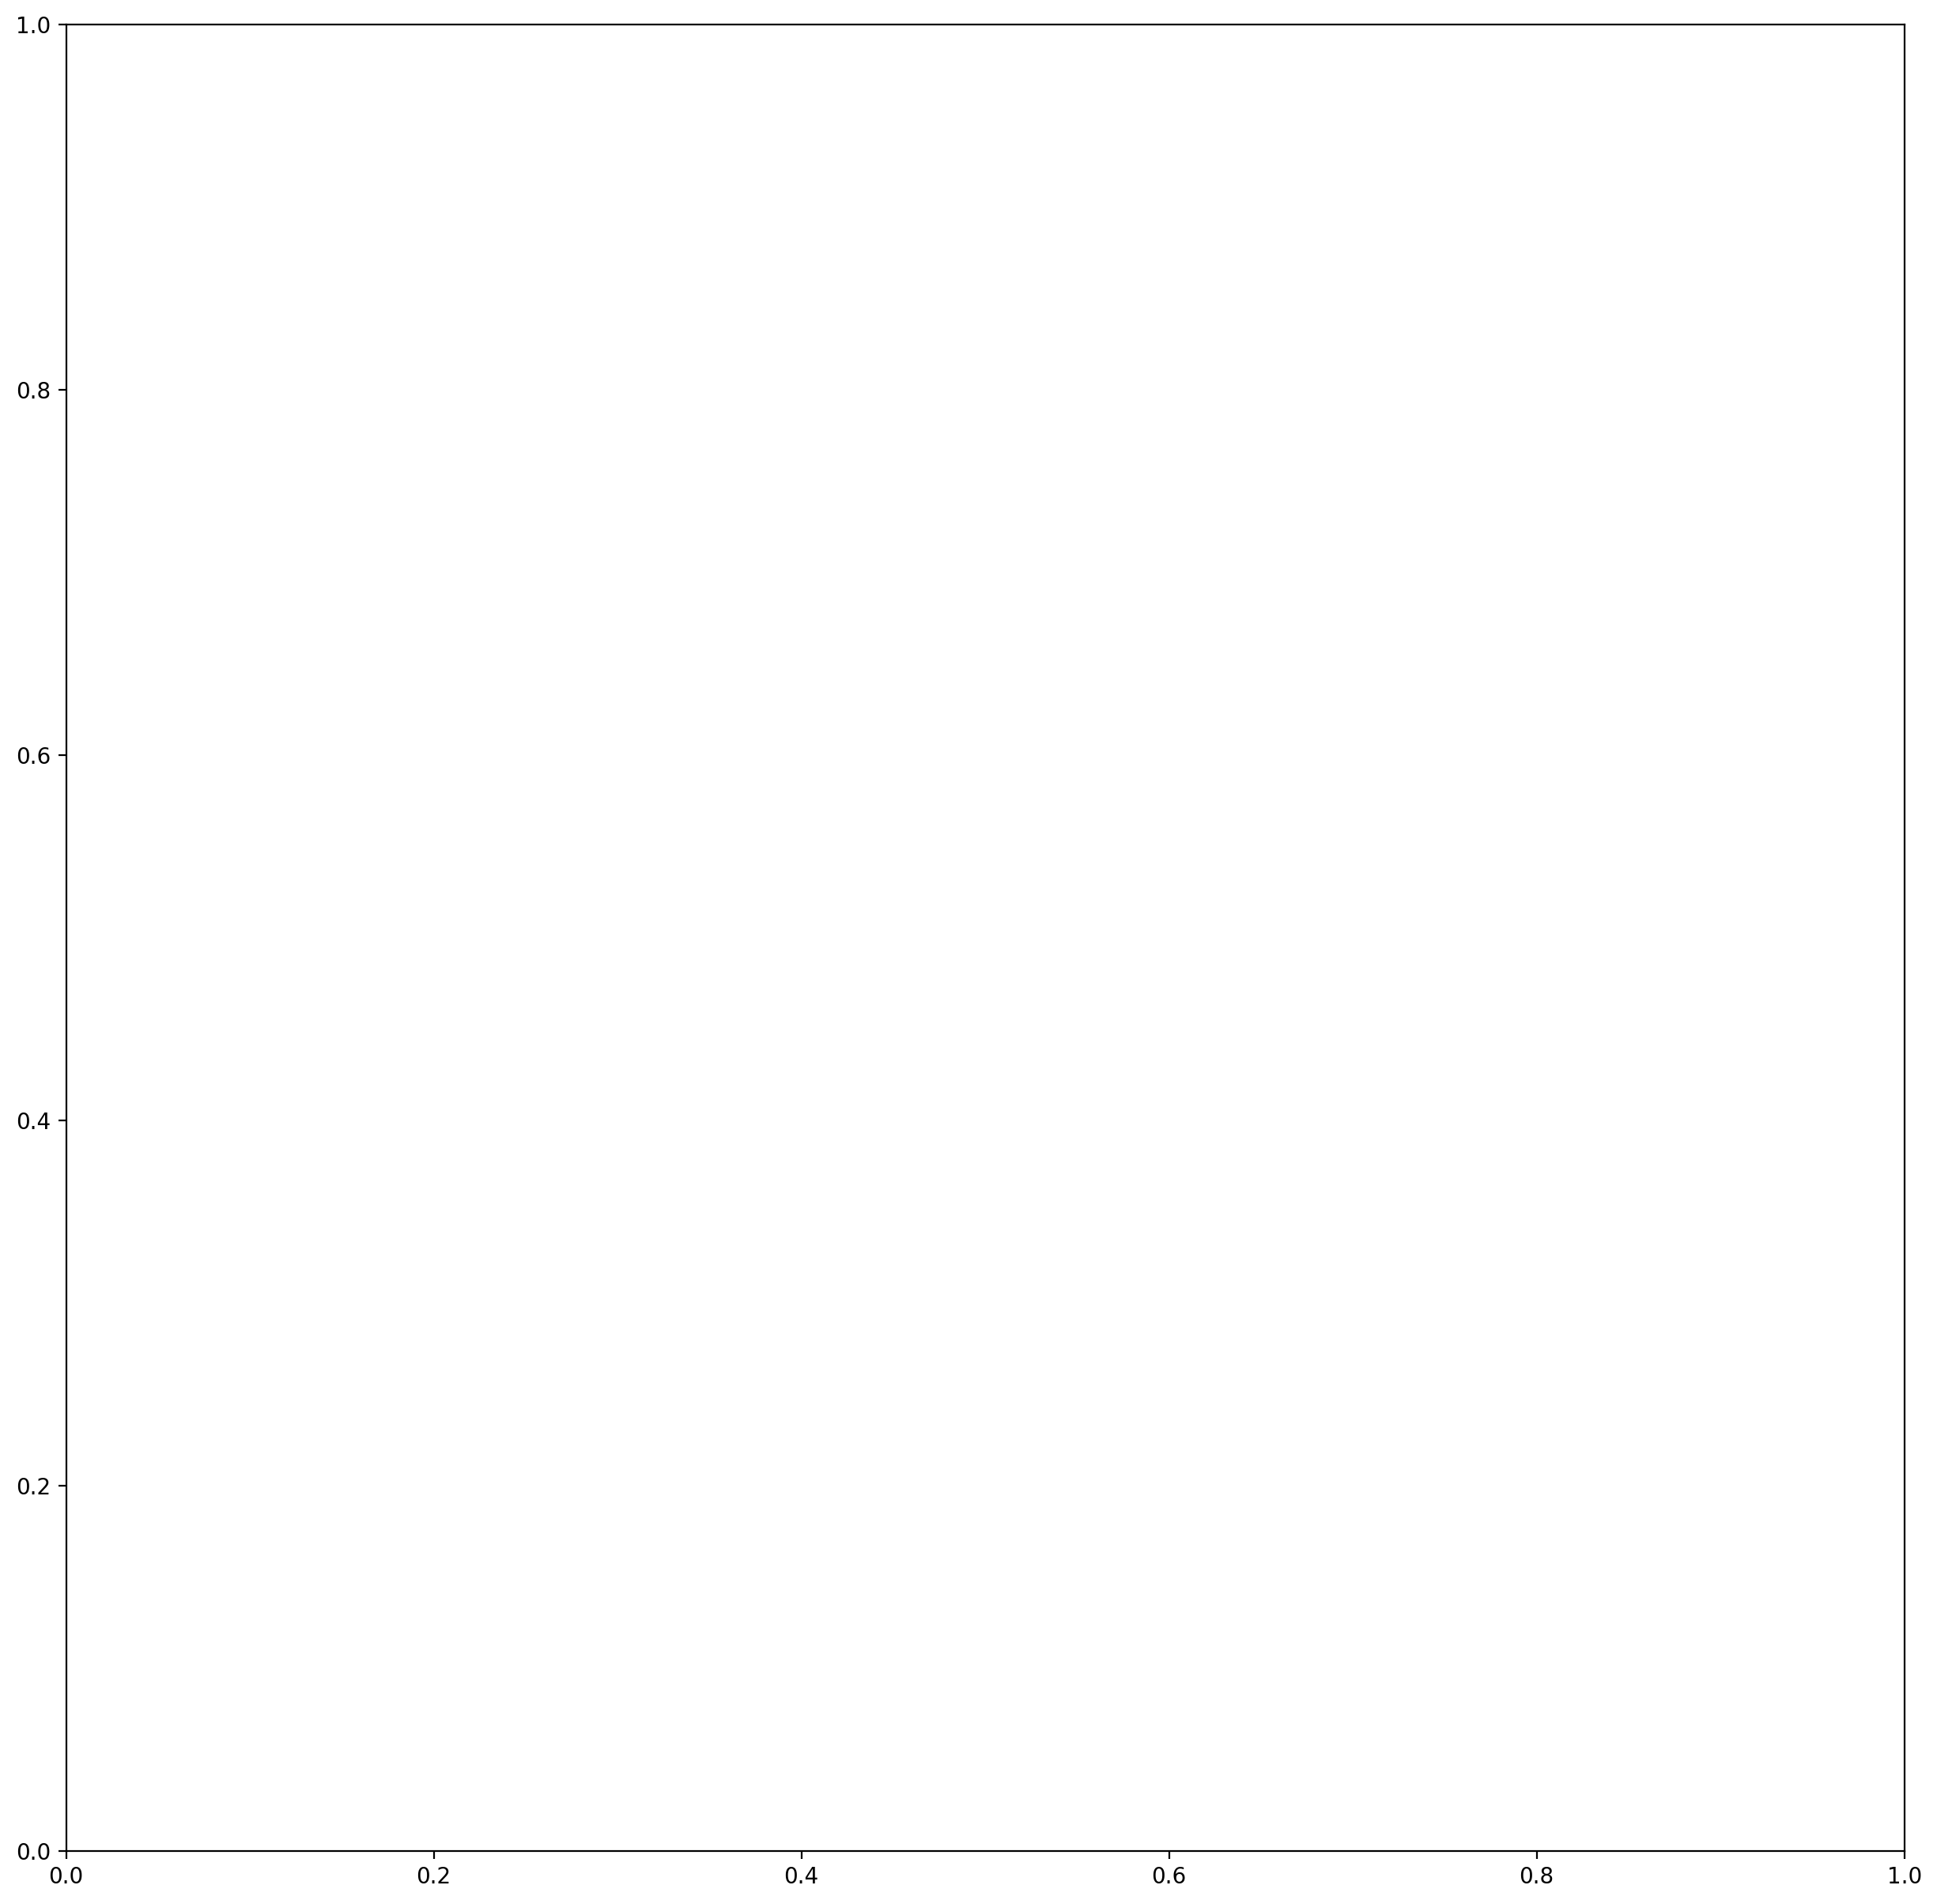

In [38]:

# Optimiser l'affichage de la heatmap
fig, ax = plt.subplots(figsize=(15, 15), dpi=200)
max_pic_count = grid_gdf_2017['pic_count'].max()
cmap = ListedColormap(plt.cm.viridis(np.linspace(0, 1, max_pic_count + 1)))

grid_gdf_2017.plot(column='pic_count', cmap=cmap, linewidth=0.2, ax=ax, edgecolor='black', alpha = 0.7)

# Ajouter la délimitation de la carte de l'Île-de-France
gdf_idf.boundary.plot(ax=ax, linewidth=1, edgecolor='black')

# Ajouter une barre de couleur
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=max_pic_count))
sm._A = []
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Nombre de pics par maille')

plt.title('Heatmap des pics de PM10 par maille de 50x50')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [ ]:
# Fusionner avec le GeoDataFrame des mailles pour inclure toutes les mailles
grid_gdf_2018 = grid_gdf.merge(pics_counts_2018, left_index=True, right_on='index_right', how='left')
# Remplacer les NaN par 0 pour les mailles sans pics
grid_gdf_2018['pic_count'].fillna(0, inplace=True)

KeyError: 'pic_count'

In [ ]:
heat_data = []

m = folium.Map(location=[48.8566, 2.3522], zoom_start=13)
for idx, row in grid_gdf.iterrows():
    # Utiliser le centroid du Polygon pour représenter son emplacement
    centroid = row['geometry'].centroid
    heat_data.append([centroid.y, centroid.x, row['pic_count']])

# Ajouter la carte de chaleur avec les données de pic_count
HeatMap(heat_data, 
        radius=15, 
        gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'orange', 0.8: 'red'}, 
        name='Pics de Pollution').add_to(m)
# Ajouter un contrôle de couches
folium.LayerControl().add_to(m)

# Sauvegarder la carte dans un fichier HTML
m.save('heatmap_pollution_events_by_month.html')
m


In [ ]:
# Préparer les données pour la carte de chaleur

events_data = []
heat_data = []

# Parcourir chaque mois pour les événements médicaux et les pics de pollution
all_months = sorted(set(df_events_2017['Date_debut'].dt.strftime('%Y-%m')))
for month in all_months:
    # Filtrer les événements médicaux pour le mois donné
    events_month = df_events_2017[df_events_2017['Date_debut'].dt.strftime('%Y-%m') == month]
    events_coords = [[row['y'], row['x']] for idx, row in events_month.iterrows()]
    events_data.append(events_coords)
    
    # # Filtrer les pics de pollution pour le mois donné
    # pics_month = grid_gdf[grid_gdf['date'].dt.strftime('%Y-%m') == month]
    # month_heat_data = [[row['geometry'].centroid.y, row['geometry'].centroid.x, row['pic_count']] for idx, row in pics_month.iterrows()]
    # heat_data.append(month_heat_data)

m = folium.Map(location=[48.8566, 2.3522], zoom_start=13)
for idx, row in grid_gdf.iterrows():
    # Utiliser le centroid du Polygon pour représenter son emplacement
    centroid = row['geometry'].centroid
    heat_data.append([centroid.y, centroid.x, row['pic_count']])

# Ajouter la carte de chaleur avec les données de pic_count
HeatMap(heat_data, 
        radius=15, 
        gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'orange', 0.8: 'red'}, 
        name='Pics de Pollution').add_to(m)


# # Ajouter la carte de chaleur pour les événements médicaux
# HeatMapWithTime(events_data, 
#                 radius=15, 
#                 gradient={0.2: 'purple', 0.4: 'blue', 0.6: 'lime', 0.8: 'yellow'}, 
#                 name='Événements Médicaux').add_to(m)

# Ajouter un contrôle de couches
folium.LayerControl().add_to(m)

# Sauvegarder la carte dans un fichier HTML
m.save('heatmap_pollution_events_by_month.html')
m